# QUEST 7
__Heatmap__

In [268]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable # колонка градиента

In [269]:
database_path = "../data/checking-logs.sqlite"

In [270]:
try:
    connection = sqlite3.connect(database=database_path)
except Exception:
    print("The connection is failed :(")

In [271]:
def check_day(x):
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    return days[x]

In [272]:
query = """
select uid, timestamp as weekday from checker
where uid like 'user_%'
"""
df = pd.io.sql.read_sql(query, connection, parse_dates=["weekday"])
df["hour"] = df["weekday"].dt.hour
df["weekday"] = df["weekday"].dt.dayofweek.apply(lambda x: check_day(x))
display(df)

,uid,weekday,hour
0,user_4,Fri,5
1,user_4,Fri,5
2,user_4,Fri,5
3,user_4,Fri,5
4,user_4,Fri,5
...,...,...,...
3202,user_1,Thu,20
3203,user_1,Thu,20
3204,user_1,Thu,20
3205,user_1,Thu,20


Нужно отсортировать колонки по возрастанию коммитов:

In [273]:
new_columns = df.groupby('uid').count().sort_values('hour', ascending=False).index
display(new_columns)

Index(['user_4', 'user_14', 'user_2', 'user_25', 'user_19', 'user_26',
       'user_20', 'user_31', 'user_10', 'user_3', 'user_29', 'user_13',
       'user_28', 'user_24', 'user_12', 'user_8', 'user_1', 'user_21',
       'user_30', 'user_18', 'user_17', 'user_16', 'user_27', 'user_15',
       'user_6', 'user_7', 'user_22', 'user_11', 'user_23', 'user_0'],
      dtype='object', name='uid')

## Heatmap 1

In [274]:
df_weekdays = df.copy()
df_weekdays = df_weekdays.drop(["hour"], axis=1)

df_weekdays["uid"] = df_weekdays["uid"].astype("category")
df_weekdays["weekday"] = df_weekdays["weekday"].astype("category")


In [275]:
df_weekdays = df_weekdays.groupby("uid").weekday.value_counts().unstack(0).fillna(0)
df_weekdays = df_weekdays.reindex(columns=new_columns, index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
display(df_weekdays)

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
Mon,35,50,24,14,7,0,23,5,0,46,...,8,10,0,0,1,0,2,0,0,3
Tue,86,87,131,44,9,1,0,0,16,11,...,4,5,0,0,0,5,3,0,0,0
Wed,33,0,32,15,0,34,8,0,37,0,...,1,0,0,0,4,3,0,0,0,0
Thu,108,17,4,40,78,51,96,7,77,7,...,17,14,15,5,2,0,2,0,6,0
Fri,61,0,0,10,10,2,7,35,1,59,...,0,0,0,0,0,0,0,0,0,0
Sat,0,79,31,66,21,16,3,90,4,3,...,32,0,0,4,2,0,0,0,0,0
Sun,45,26,13,44,51,69,28,7,2,8,...,0,31,27,20,9,0,1,8,0,0


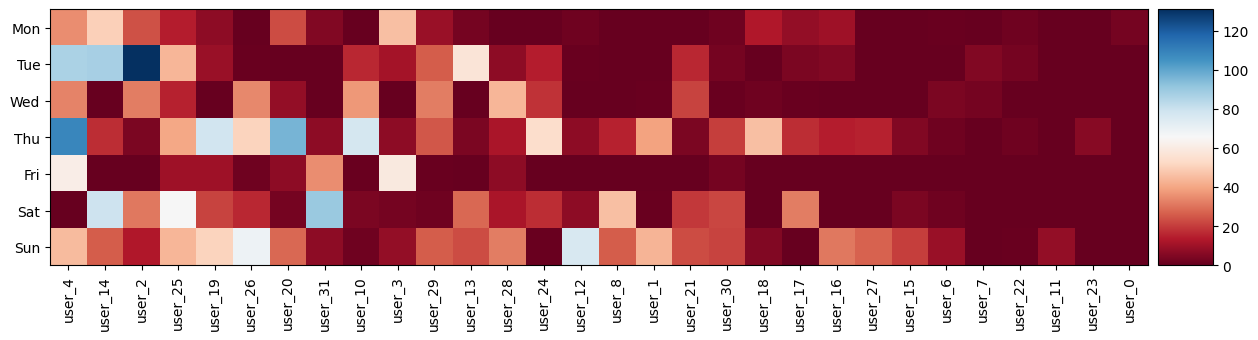

In [276]:
fig, ax = plt.subplots(figsize=(15, 8))
pic = ax.imshow(df_weekdays, cmap="RdBu")

ax.set_xticks(range(df_weekdays.shape[1]))
ax.set_xticklabels(df_weekdays.columns, rotation = 90)
ax.set_yticks(range(df_weekdays.shape[0]))
ax.set_yticklabels(df_weekdays.index)

# колонка градиента
gradient = make_axes_locatable(ax)
cax = gradient.append_axes("right", size="5%", pad=0.1)     # сторона, размер, ближе к диаграмме
plt.colorbar(pic, cax=cax)

plt.show()

## Heatmap 2

Таблица для 2 диаграммы:

In [277]:
df_hours = df.copy()
df_hours.drop(["weekday"], axis=1, inplace=True)

df_hours["uid"] = df_hours["uid"].astype("category")

Отсортируем юзеров по колоичеству коммитов и заполним недостоющие часы:

In [278]:
df_hours = df_hours.groupby("uid").hour.value_counts().unstack(0).fillna(0)
df_hours = df_hours.reindex(columns=new_columns, index=range(0, 24))
df_hours.fillna(0, inplace=True)
display(df_hours)

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,3.0,6.0,0.0,0.0,10.0,2.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,6.0,0.0,0.0,0.0,5.0,2.0,0.0,9.0,6.0,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


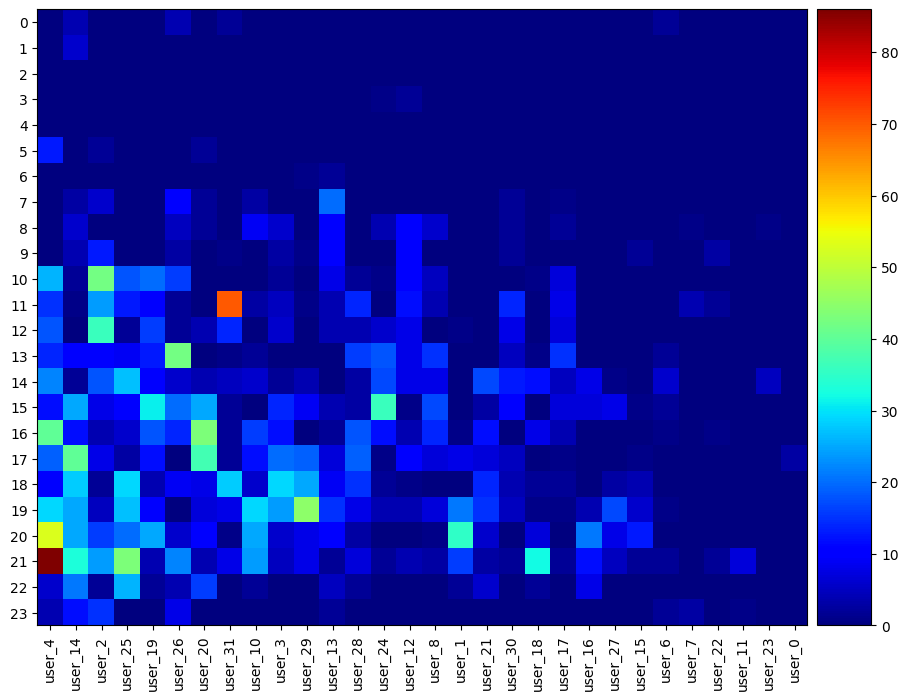

In [279]:
fig, ax = plt.subplots(figsize=(15, 8))
pic = ax.imshow(df_hours, cmap="jet") # blue -> green -> yellow -> red

ax.set_xticks(range(df_hours.shape[1]))
ax.set_xticklabels(df_hours.columns, rotation=90)
ax.set_yticks(range(df_hours.shape[0]))
ax.set_yticklabels(df_hours.index)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="7%", pad=0.1)     # сторона, размер, ближе к диаграмме
plt.colorbar(pic, cax=cax)


In [280]:
""" Графики вместе
fig, ax = plt.subplots(2, 1, figsize=(15, 30))
pic = ax[0].imshow(df_weekdays, cmap="RdBu")

ax[0].set_xticks(range(df_weekdays.shape[1]))
ax[0].set_xticklabels(df_weekdays.columns, rotation = 90)
ax[0].set_yticks(range(df_weekdays.shape[0]))
ax[0].set_yticklabels(df_weekdays.index)

# колонка градиента
gradient = make_axes_locatable(ax[0])
cax = gradient.append_axes("right", size="5%", pad=0.1)     # сторона, размер, ближе к диаграмме
plt.colorbar(pic, cax=cax)

pic = ax[1].imshow(df_hours, cmap="jet") # blue -> green -> yellow -> red

ax[1].set_xticks(range(df_hours.shape[1]))
ax[1].set_xticklabels(df_hours.columns, rotation=90)
ax[1].set_yticks(range(df_hours.shape[0]))
ax[1].set_yticklabels(df_hours.index)

# колонка градиента
gradient = make_axes_locatable(ax[1])
cax = gradient.append_axes("right", size="7%", pad=0.1)     # сторона, размер, ближе к диаграмме
plt.colorbar(pic, cax=cax)
plt.show()"
"""

' Графики вместе\nfig, ax = plt.subplots(2, 1, figsize=(15, 30))\npic = ax[0].imshow(df_weekdays, cmap="RdBu")\n\nax[0].set_xticks(range(df_weekdays.shape[1]))\nax[0].set_xticklabels(df_weekdays.columns, rotation = 90)\nax[0].set_yticks(range(df_weekdays.shape[0]))\nax[0].set_yticklabels(df_weekdays.index)\n\n# колонка градиента\ngradient = make_axes_locatable(ax[0])\ncax = gradient.append_axes("right", size="5%", pad=0.1)     # сторона, размер, ближе к диаграмме\nplt.colorbar(pic, cax=cax)\n\npic = ax[1].imshow(df_hours, cmap="jet") # blue -> green -> yellow -> red\n\nax[1].set_xticks(range(df_hours.shape[1]))\nax[1].set_xticklabels(df_hours.columns, rotation=90)\nax[1].set_yticks(range(df_hours.shape[0]))\nax[1].set_yticklabels(df_hours.index)\n\n# колонка градиента\ngradient = make_axes_locatable(ax[1])\ncax = gradient.append_axes("right", size="7%", pad=0.1)     # сторона, размер, ближе к диаграмме\nplt.colorbar(pic, cax=cax)\nplt.show()"\n'

## Вопросы

### Which user has the most commits on Tue?

user_2

### Which user has the most commits on Thu?

user_4

### On which weekday do the users not like making a lot of commits?

Fri - 
Проверим кодом:

In [292]:
sums = df_weekdays.sum(axis=1)
min_weekay = sums.idxmin()
print(min_weekay)

Fri


### Which user at which hour made the largest number of commits?

user_4 at 21

In [281]:
connection.close()